# Gaussian Naive Bayes

**Owner: Student 3 | Review 1 - Classification Part A**  
**Working assumption:** No separate classification dataset was supplied, so this notebook predicts `smoker` from the available health-insurance predictors. `claim` is excluded to prevent downstream target-proxy leakage.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

SEED = 42
sns.set_theme(style="whitegrid", palette="colorblind")
repo_root = next(
    (parent for parent in (Path.cwd(), *Path.cwd().parents)
     if (parent / "data" / "health_insurance.csv").exists()),
    None,
)
if repo_root is None:
    raise FileNotFoundError("Run this notebook from inside the ML-301 repository.")

raw_df = pd.read_csv(repo_root / "data" / "health_insurance.csv")
df = raw_df.drop_duplicates().copy()
y = df["smoker"]
# Claim is downstream of smoking status and would act as a target proxy.
X = df.drop(columns=["smoker", "claim"])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()
X_train = X_train.copy()
X_test = X_test.copy()
for frame in (X_train, X_test):
    frame["age_bmi_interaction"] = frame["age"] * frame["bmi"]
numeric_features.append("age_bmi_interaction")

preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]), numeric_features),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)),
    ]), categorical_features),
])
results_dir = repo_root / "results" / "classification_results"
results_dir.mkdir(parents=True, exist_ok=True)
print(f"Target: smoker | train={len(X_train):,}, test={len(X_test):,}")
display(y.value_counts().rename("count").to_frame())

Target: smoker | train=11,123, test=2,781


,count
smoker,
0,11114
1,2790


In [2]:
from sklearn.naive_bayes import GaussianNB

model = Pipeline([("preprocessor", preprocessor), ("classifier", GaussianNB())])
model.fit(X_train, y_train)
model_name = "Gaussian Naive Bayes"
result_file = "03_gaussian_naive_bayes.csv"

,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC
0,Gaussian Naive Bayes,0.83,0.811,0.83,0.81,0.708


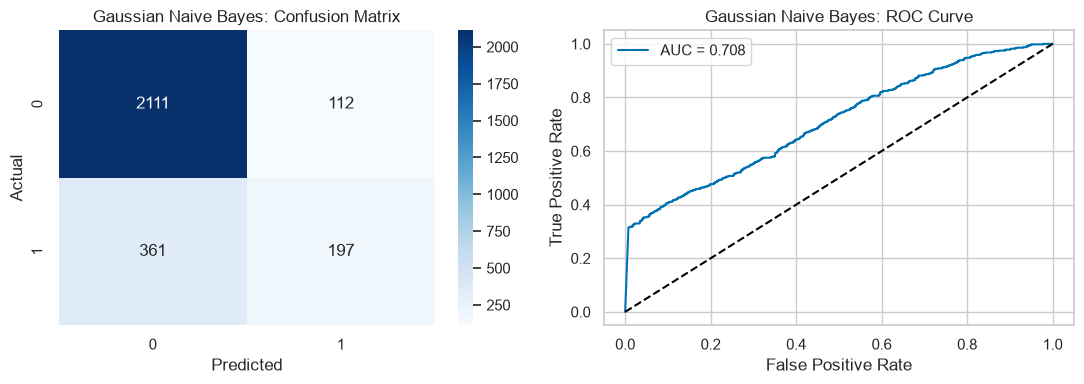

In [3]:
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve,
)

y_pred = model.predict(X_test)
y_score = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
metrics = pd.DataFrame({
    "Model": [model_name],
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Precision_weighted": [precision_score(y_test, y_pred, average="weighted", zero_division=0)],
    "Recall_weighted": [recall_score(y_test, y_pred, average="weighted", zero_division=0)],
    "F1_weighted": [f1_score(y_test, y_pred, average="weighted", zero_division=0)],
    "ROC_AUC": [roc_auc_score(y_test, y_score)],
})
display(metrics.round(3))
metrics.to_csv(results_dir / result_file, index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set(title=f"{model_name}: Confusion Matrix", xlabel="Predicted", ylabel="Actual")
fpr, tpr, _ = roc_curve(y_test, y_score)
axes[1].plot(fpr, tpr, label=f"AUC = {metrics.loc[0, 'ROC_AUC']:.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="black")
axes[1].set(title=f"{model_name}: ROC Curve", xlabel="False Positive Rate", ylabel="True Positive Rate")
axes[1].legend()
plt.tight_layout()
plt.show()
assert np.isfinite(metrics.select_dtypes(include=np.number).to_numpy()).all()

### Interpretation

Gaussian Naive Bayes assumes conditional independence and Gaussian numeric distributions; correlated health features make this a deliberately simple baseline.